✓ Ready
Loading: C:\python\Intelligent_Sketch2CAD\intermediate_data\adaptive_cleaned_20260510_143013.jpg
Main contour area: 708012 px


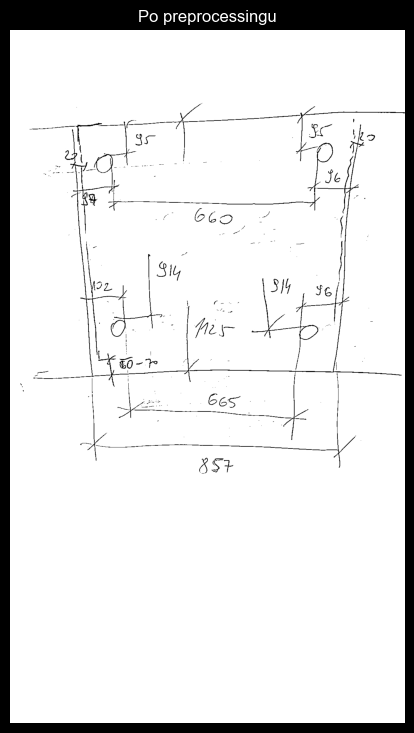

✓ Preprocessing OK

--- Krok 1: Thinning ---


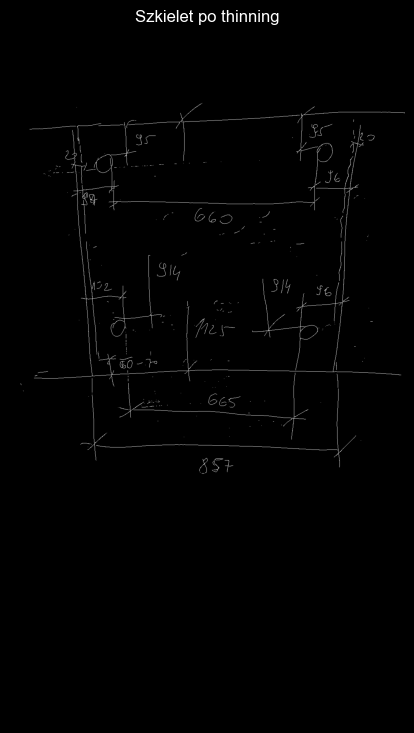

✓ Thinning OK

--- Krok 2: DeepLSD ---
✓ Model załadowany
DeepLSD wykrył: 344 surowych segmentów


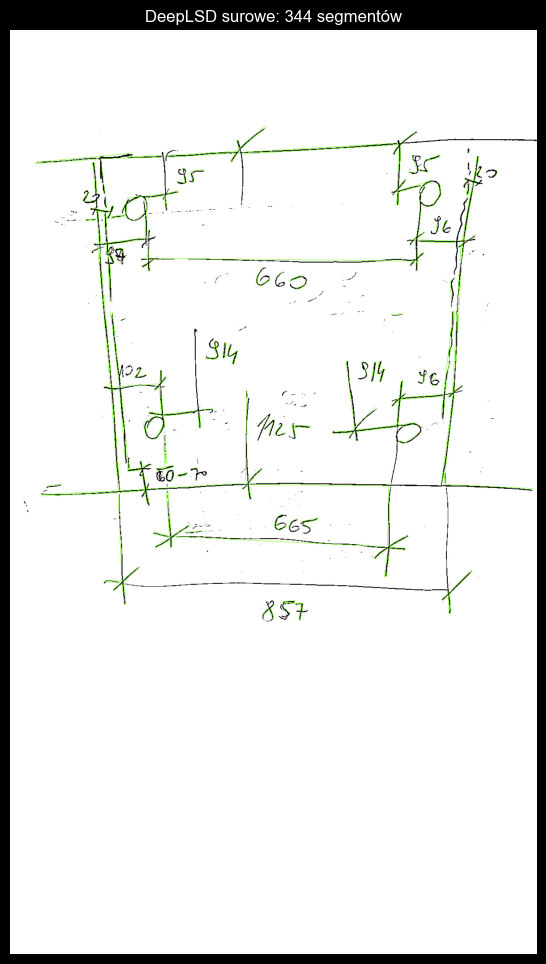


--- Krok 3: Klasyfikacja ---
main=54, wymiarowe=38, ticki=53, inne=1


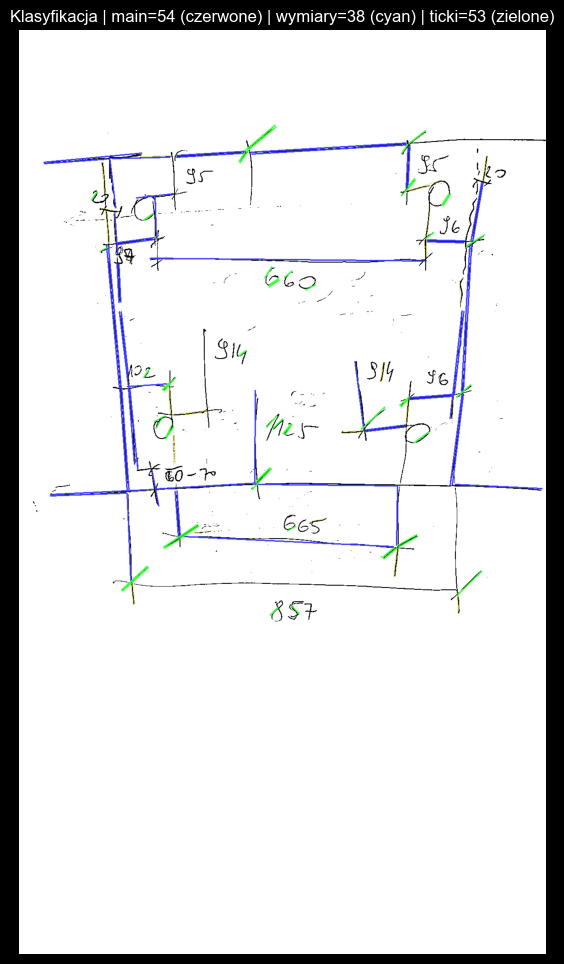


--- Krok 4: Prostokąt ---
Scalone poziome: 7, pionowe: 5
  H: Y=272  x=54→847  len=793px  (z 7 segm.)
  H: Y=362  x=256→337  len=81px  (z 1 segm.)
  H: Y=469  x=215→974  len=759px  (z 5 segm.)
  H: Y=794  x=236→947  len=711px  (z 3 segm.)
  H: Y=871  x=756→845  len=89px  (z 2 segm.)
  H: Y=1003  x=68→1143  len=1075px  (z 5 segm.)
  H: Y=1119  x=360→818  len=458px  (z 1 segm.)
  V: X=247  y=280→1205  len=925px  (z 17 segm.)
  V: X=515  y=788→990  len=202px  (z 1 segm.)
  V: X=743  y=725→872  len=147px  (z 1 segm.)
  V: X=842  y=252→1127  len=875px  (z 3 segm.)
  V: X=973  y=333→996  len=663px  (z 8 segm.)
Prostokąt outer: (247,272)→(842,1003)  595x731px

--- Krok 5: Snap rogów ---
Snap: poprawiono 52 końców linii (dist < 40px)


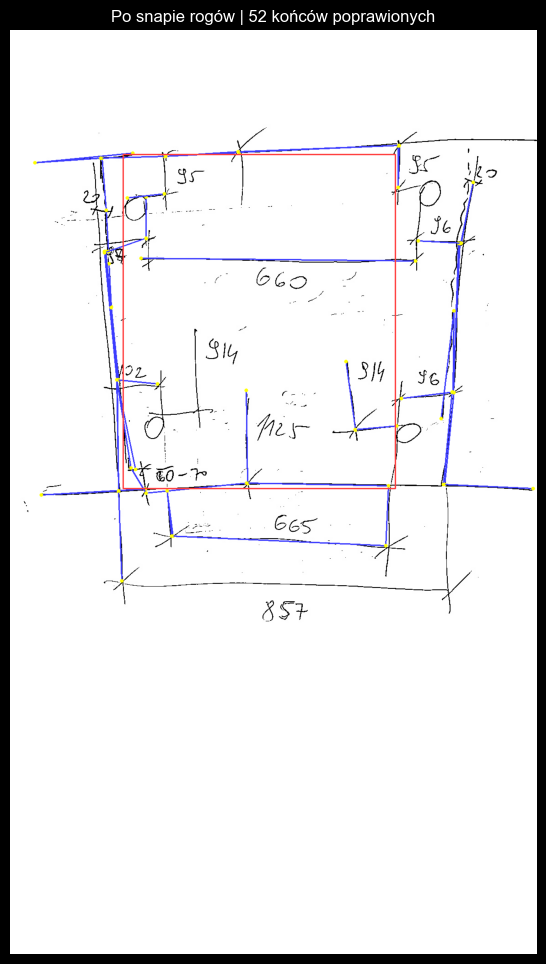


--- Krok 6: Okręgi ---
  mounting_1: (870,882)  r=28px  okrągłość=0.81
  mounting_2: (275,388)  r=28px  okrągłość=0.77
  mounting_3: (916,357)  r=28px  okrągłość=0.72
  mounting_4: (317,870)  r=25px  okrągłość=0.70

--- Krok 7: Wizualizacja końcowa ---


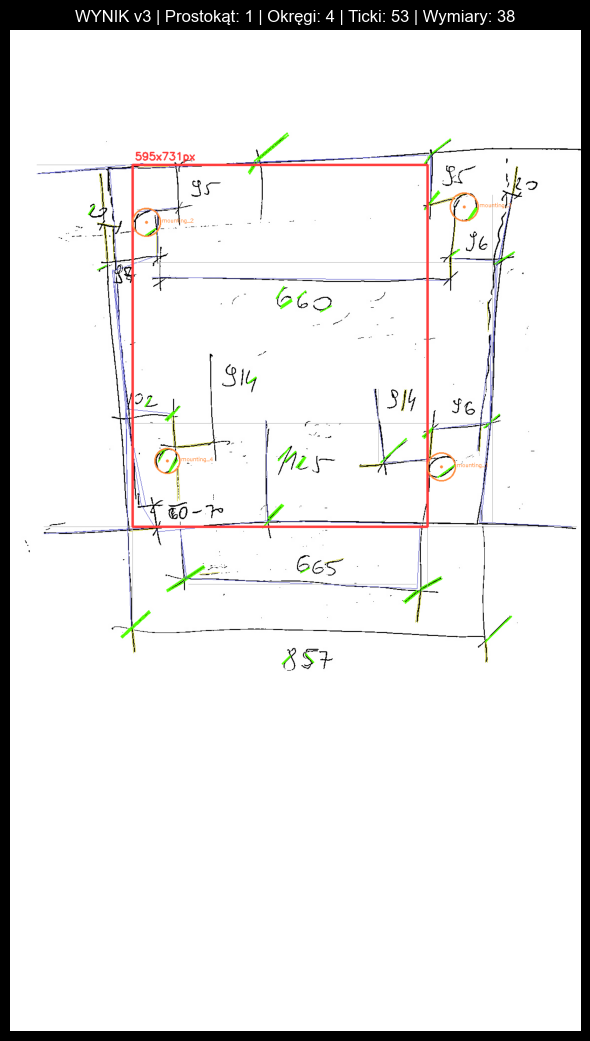


✅ Zapisano: C:\python\Intelligent_Sketch2CAD\intermediate_data\deeplsd_v3_20260511_015737.json
   Prostokąt: 1
   Okręgi montażowe: 4
   Linie wymiarowe: 38
   Ticki: 53
   Snap poprawił: 52 końców

→ Następny krok: eksport DXF dla FreeCAD


In [4]:
# -------------------------------
# SKETCH → CAD: DeepLSD + okręgi v3
# -------------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os
import json
from datetime import datetime
import torch
import sys

print("✓ Ready")

# -------------------------------
# PATHS
# -------------------------------
PROJECT_DIR = Path(r"C:\python\Intelligent_Sketch2CAD")
INTERMEDIATE_DIR = PROJECT_DIR / "intermediate_data"
DEEPLSD_DIR = PROJECT_DIR / "DeepLSD"
WEIGHTS_PATH = DEEPLSD_DIR / "weights" / "deeplsd_md.tar"

# -------------------------------
# LOAD IMAGE
# -------------------------------
pattern = str(INTERMEDIATE_DIR / "adaptive_cleaned_*.jpg")
files = glob.glob(pattern)
if not files:
    raise FileNotFoundError("No adaptive_cleaned_*.jpg found.")
latest_file = max(files, key=os.path.getctime)
print(f"Loading: {latest_file}")

image = cv2.imread(latest_file)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape) == 3 else image
if np.mean(gray) < 128:
    gray = cv2.bitwise_not(gray)
    print("Polarity fixed")

# ============================================================
# PREPROCESSING (oryginalny)
# ============================================================
contour_img = cv2.bitwise_not(gray)
contours, _ = cv2.findContours(contour_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not contours:
    gray_filtered = gray
else:
    main_contour = max(contours, key=cv2.contourArea)
    print(f"Main contour area: {cv2.contourArea(main_contour):.0f} px")

    mask_inside = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_inside, [main_contour], -1, 255, thickness=cv2.FILLED)

    mask_edge = np.zeros_like(gray, dtype=np.uint8)
    cv2.drawContours(mask_edge, [main_contour], -1, 255, thickness=2)
    mask_near = cv2.dilate(mask_edge, np.ones((120, 120), np.uint8), iterations=1)

    cc_img = cv2.bitwise_not(gray)
    _, labels, stats, _ = cv2.connectedComponentsWithStats(cc_img, connectivity=8)
    mask_final = np.zeros_like(gray, dtype=np.uint8)

    for label in range(1, len(stats)):
        comp_mask = (labels == label).astype(np.uint8) * 255
        area = stats[label, cv2.CC_STAT_AREA]
        if cv2.bitwise_and(comp_mask, mask_inside).any():
            mask_final = cv2.bitwise_or(mask_final, comp_mask)
        elif cv2.bitwise_and(comp_mask, mask_near).any() and area < 1500:
            mask_final = cv2.bitwise_or(mask_final, comp_mask)

    gray_filtered = cv2.bitwise_and(gray, mask_final)
    gray_filtered[mask_final == 0] = 255
    gray = gray_filtered

plt.figure(figsize=(6, 9))
plt.imshow(gray, cmap='gray')
plt.title("Po preprocessingu")
plt.axis('off')
plt.show()
print("✓ Preprocessing OK")

# ============================================================
# 1. THINNING
# ============================================================
print("\n--- Krok 1: Thinning ---")
binary_thin = cv2.bitwise_not(gray)
skeleton = cv2.ximgproc.thinning(binary_thin, thinningType=cv2.ximgproc.THINNING_ZHANGSUEN)
h, w = skeleton.shape

plt.figure(figsize=(6, 9))
plt.imshow(skeleton, cmap='gray')
plt.title("Szkielet po thinning")
plt.axis('off')
plt.show()
print("✓ Thinning OK")

# ============================================================
# 2. DeepLSD
# ============================================================
print("\n--- Krok 2: DeepLSD ---")
sys.path.insert(0, str(DEEPLSD_DIR))
from deeplsd.models.deeplsd_inference import DeepLSD

device = torch.device('cpu')
conf = {
    'detect_lines': True,
    'line_detection_params': {
        'merge': True,
        'filtering': True,
        'grad_thresh': 2,
        'grad_nfa': True,
    }
}

ckpt = torch.load(str(WEIGHTS_PATH), map_location=device, weights_only=False)
net = DeepLSD(conf)
net.load_state_dict(ckpt['model'])
net.eval()
print("✓ Model załadowany")

img_tensor = torch.tensor(gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

with torch.no_grad():
    out = net({'image': img_tensor})

lines_raw = out['lines'][0]
print(f"DeepLSD wykrył: {len(lines_raw)} surowych segmentów")

all_segments = []
for line in lines_raw:
    x1, y1 = float(line[0][0]), float(line[0][1])
    x2, y2 = float(line[1][0]), float(line[1][1])
    length = np.hypot(x2 - x1, y2 - y1)
    angle = np.degrees(np.arctan2(y2 - y1, x2 - x1)) % 180
    all_segments.append((int(x1), int(y1), int(x2), int(y2), length, angle))

vis_raw = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for (x1, y1, x2, y2, length, angle) in all_segments:
    cv2.line(vis_raw, (x1, y1), (x2, y2), (0, 255, 100), 1)

plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis_raw, cv2.COLOR_BGR2RGB))
plt.title(f"DeepLSD surowe: {len(all_segments)} segmentów")
plt.axis('off')
plt.show()

# ============================================================
# 3. KLASYFIKACJA
# ============================================================
print("\n--- Krok 3: Klasyfikacja ---")

ANGLE_TOL_STRAIGHT = 20
ANGLE_TOL_TICK = 18
MIN_MAIN = 80      # obniżone — łapie też dolną linię wymiarową
MIN_DIM  = 40
MIN_TICK = 20
MAX_TICK = 90

def classify_segment(x1, y1, x2, y2, length, angle):
    is_horizontal = (angle < ANGLE_TOL_STRAIGHT or
                     angle > (180 - ANGLE_TOL_STRAIGHT))
    is_vertical   = abs(angle - 90) < ANGLE_TOL_STRAIGHT
    is_straight   = is_horizontal or is_vertical
    is_tick_angle = (abs(angle - 45) < ANGLE_TOL_TICK or
                     abs(angle - 135) < ANGLE_TOL_TICK)

    if is_straight and length >= MIN_MAIN:
        return "main"
    elif is_straight and length >= MIN_DIM:
        return "dimension_line"
    elif is_tick_angle and MIN_TICK <= length <= MAX_TICK:
        return "tick"
    elif length >= MIN_DIM:
        return "other"
    else:
        return "noise"

lines_main      = []
lines_dimension = []
lines_tick      = []
lines_other     = []

for seg in all_segments:
    x1, y1, x2, y2, length, angle = seg
    typ = classify_segment(x1, y1, x2, y2, length, angle)
    entry = {"x1": x1, "y1": y1, "x2": x2, "y2": y2,
             "length_px": round(length, 1), "angle_deg": round(angle, 1)}
    if typ == "main":
        lines_main.append(entry)
    elif typ == "dimension_line":
        lines_dimension.append(entry)
    elif typ == "tick":
        lines_tick.append(entry)
    elif typ == "other":
        lines_other.append(entry)

# Długie linie "other" → main (pochylone krawędzie)
for l in lines_other:
    if l['length_px'] > 150:
        lines_main.append(l)

print(f"main={len(lines_main)}, wymiarowe={len(lines_dimension)}, "
      f"ticki={len(lines_tick)}, inne={len(lines_other)}")

vis_class = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for l in lines_main:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (255, 60, 60), 2)
for l in lines_dimension:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (60, 220, 220), 1)
for l in lines_tick:
    cv2.line(vis_class, (l['x1'],l['y1']), (l['x2'],l['y2']), (60, 255, 60), 2)

plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis_class, cv2.COLOR_BGR2RGB))
plt.title(f"Klasyfikacja | main={len(lines_main)} (czerwone) | "
          f"wymiary={len(lines_dimension)} (cyan) | ticki={len(lines_tick)} (zielone)")
plt.axis('off')
plt.show()

# ============================================================
# 4. SCALANIE + PROSTOKĄT z 2 najdłuższych H i V
# ============================================================
print("\n--- Krok 4: Prostokąt ---")

def merge_parallel_lines(lines, axis='h', gap=60):
    if not lines:
        return []
    key_fn = (lambda l: (l['y1'] + l['y2']) / 2) if axis == 'h' \
             else (lambda l: (l['x1'] + l['x2']) / 2)

    sorted_lines = sorted(lines, key=key_fn)
    groups, group = [], [sorted_lines[0]]

    for line in sorted_lines[1:]:
        if abs(key_fn(line) - key_fn(group[-1])) < gap:
            group.append(line)
        else:
            groups.append(group)
            group = [line]
    groups.append(group)

    result = []
    for grp in groups:
        if axis == 'h':
            y_avg = int(np.mean([(l['y1'] + l['y2']) / 2 for l in grp]))
            x_min = min(min(l['x1'], l['x2']) for l in grp)
            x_max = max(max(l['x1'], l['x2']) for l in grp)
            result.append({'y': y_avg, 'x1': x_min, 'x2': x_max,
                           'length': x_max - x_min, 'count': len(grp)})
        else:
            x_avg = int(np.mean([(l['x1'] + l['x2']) / 2 for l in grp]))
            y_min = min(min(l['y1'], l['y2']) for l in grp)
            y_max = max(max(l['y1'], l['y2']) for l in grp)
            result.append({'x': x_avg, 'y1': y_min, 'y2': y_max,
                           'length': y_max - y_min, 'count': len(grp)})
    return result

main_h = [l for l in lines_main
          if l['angle_deg'] < ANGLE_TOL_STRAIGHT or
             l['angle_deg'] > (180 - ANGLE_TOL_STRAIGHT)]
main_v = [l for l in lines_main
          if abs(l['angle_deg'] - 90) < ANGLE_TOL_STRAIGHT]

merged_h = merge_parallel_lines(main_h, axis='h', gap=60)
merged_v = merge_parallel_lines(main_v, axis='v', gap=60)

print(f"Scalone poziome: {len(merged_h)}, pionowe: {len(merged_v)}")
for l in merged_h:
    print(f"  H: Y={l['y']}  x={l['x1']}→{l['x2']}  len={l['length']}px  "
          f"(z {l['count']} segm.)")
for l in merged_v:
    print(f"  V: X={l['x']}  y={l['y1']}→{l['y2']}  len={l['length']}px  "
          f"(z {l['count']} segm.)")

# POPRAWKA: prostokąt z 2 NAJDŁUŻSZYCH H i 2 NAJDŁUŻSZYCH V
rectangles = []
top_h = sorted(merged_h, key=lambda l: -l['length'])[:2]
top_v = sorted(merged_v, key=lambda l: -l['length'])[:2]

if len(top_h) >= 2 and len(top_v) >= 2:
    h_ys = sorted([l['y'] for l in top_h])
    v_xs = sorted([l['x'] for l in top_v])
    rectangles.append({
        "label": "outer",
        "x1": v_xs[0], "y1": h_ys[0],
        "x2": v_xs[1], "y2": h_ys[1],
        "width_px":  v_xs[1] - v_xs[0],
        "height_px": h_ys[1] - h_ys[0]
    })
    r = rectangles[0]
    print(f"Prostokąt outer: ({r['x1']},{r['y1']})→({r['x2']},{r['y2']})  "
          f"{r['width_px']}x{r['height_px']}px")
else:
    print("⚠ Za mało linii do wyznaczenia prostokąta")

# ============================================================
# 5. SNAP KOŃCÓW LINII (domknięcie rogów)
# ============================================================
print("\n--- Krok 5: Snap rogów ---")

SNAP_DIST = 40   # piksele — jeśli dwa końce są bliżej, połącz

def get_endpoints(lines):
    """Zwraca listę (x, y, line_idx, end_idx) dla wszystkich końców."""
    pts = []
    for i, l in enumerate(lines):
        pts.append((l['x1'], l['y1'], i, 0))
        pts.append((l['x2'], l['y2'], i, 1))
    return pts

def snap_endpoints(lines, snap_dist=40):
    """Snap: przesuń końce linii które są blisko siebie do wspólnego punktu."""
    lines = [l.copy() for l in lines]
    endpoints = get_endpoints(lines)

    for i in range(len(endpoints)):
        x1, y1, li, ei = endpoints[i]
        for j in range(i + 1, len(endpoints)):
            x2, y2, lj, ej = endpoints[j]
            if li == lj:
                continue
            dist = np.hypot(x2 - x1, y2 - y1)
            if dist < snap_dist:
                # Snap do średniej
                mx, my = int((x1 + x2) / 2), int((y1 + y2) / 2)
                if ei == 0:
                    lines[li]['x1'], lines[li]['y1'] = mx, my
                else:
                    lines[li]['x2'], lines[li]['y2'] = mx, my
                if ej == 0:
                    lines[lj]['x1'], lines[lj]['y1'] = mx, my
                else:
                    lines[lj]['x2'], lines[lj]['y2'] = mx, my
                # Aktualizuj endpoints
                endpoints[i] = (mx, my, li, ei)
                endpoints[j] = (mx, my, lj, ej)
    return lines

# Snap na liniach głównych
lines_main_snapped = snap_endpoints(lines_main, snap_dist=SNAP_DIST)
snapped_count = sum(
    1 for a, b in zip(lines_main, lines_main_snapped)
    if (a['x1'] != b['x1'] or a['y1'] != b['y1'] or
        a['x2'] != b['x2'] or a['y2'] != b['y2'])
)
print(f"Snap: poprawiono {snapped_count} końców linii (dist < {SNAP_DIST}px)")

# Wizualizacja po snapie
vis_snap = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for l in lines_main_snapped:
    cv2.line(vis_snap, (l['x1'],l['y1']), (l['x2'],l['y2']), (255, 60, 60), 2)
    # Zaznacz końce
    cv2.circle(vis_snap, (l['x1'],l['y1']), 4, (0, 255, 255), -1)
    cv2.circle(vis_snap, (l['x2'],l['y2']), 4, (0, 255, 255), -1)

if rectangles:
    r = rectangles[0]
    cv2.rectangle(vis_snap, (r['x1'],r['y1']), (r['x2'],r['y2']),
                  (60, 60, 255), 2)

plt.figure(figsize=(8, 12))
plt.imshow(cv2.cvtColor(vis_snap, cv2.COLOR_BGR2RGB))
plt.title(f"Po snapie rogów | {snapped_count} końców poprawionych")
plt.axis('off')
plt.show()

# ============================================================
# 6. OKRĘGI
# ============================================================
print("\n--- Krok 6: Okręgi ---")

kernel_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
skeleton_closed = cv2.morphologyEx(skeleton, cv2.MORPH_CLOSE, kernel_close)
circle_contours, _ = cv2.findContours(skeleton_closed, cv2.RETR_LIST,
                                       cv2.CHAIN_APPROX_SIMPLE)

circles_all = []
for cnt in circle_contours:
    area = cv2.contourArea(cnt)
    if area < 300 or area > 12000:
        continue
    perimeter = cv2.arcLength(cnt, True)
    if perimeter < 1:
        continue
    circularity = 4 * np.pi * area / (perimeter ** 2)
    if circularity > 0.60:
        (cx, cy), radius = cv2.minEnclosingCircle(cnt)
        circles_all.append({
            "cx": int(cx), "cy": int(cy),
            "radius_px": int(radius),
            "circularity": round(circularity, 3)
        })

circles_clean = []
for c in sorted(circles_all, key=lambda x: -x['radius_px']):
    if not any(np.hypot(c['cx']-e['cx'], c['cy']-e['cy']) < 25
               for e in circles_clean):
        circles_clean.append(c)

circles_mounting = sorted(circles_clean, key=lambda x: -x['radius_px'])[:4]
for i, c in enumerate(circles_mounting):
    c['label'] = f"mounting_{i+1}"
    c['radius_mm'] = None
    print(f"  {c['label']}: ({c['cx']},{c['cy']})  r={c['radius_px']}px  "
          f"okrągłość={c['circularity']:.2f}")

# ============================================================
# 7. WIZUALIZACJA KOŃCOWA
# ============================================================
print("\n--- Krok 7: Wizualizacja końcowa ---")

vis_final = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

# Linie wymiarowe (cyan)
for l in lines_dimension:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']),
             (0, 200, 200), 1)

# Ticki (zielone)
for l in lines_tick:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']),
             (0, 255, 80), 2)

# Linie główne po snapie (niebieskie)
for l in lines_main_snapped:
    cv2.line(vis_final, (l['x1'],l['y1']), (l['x2'],l['y2']),
             (200, 80, 80), 1)

# Scalone H i V (białe)
for l in merged_h:
    cv2.line(vis_final, (l['x1'], l['y']), (l['x2'], l['y']),
             (180, 180, 180), 1)
for l in merged_v:
    cv2.line(vis_final, (l['x'], l['y1']), (l['x'], l['y2']),
             (180, 180, 180), 1)

# Prostokąt (czerwony, gruby)
for r in rectangles:
    cv2.rectangle(vis_final, (r['x1'],r['y1']), (r['x2'],r['y2']),
                  (60, 60, 255), 3)
    cv2.putText(vis_final, f"{r['width_px']}x{r['height_px']}px",
                (r['x1']+5, r['y1']-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (60, 60, 255), 2)

# Okręgi (pomarańczowe)
for c in circles_mounting:
    cv2.circle(vis_final, (c['cx'],c['cy']), c['radius_px'], (60, 140, 255), 2)
    cv2.circle(vis_final, (c['cx'],c['cy']), 3, (60, 140, 255), -1)
    cv2.putText(vis_final, c['label'],
                (c['cx']+c['radius_px']+3, c['cy']),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (60, 140, 255), 1)

plt.figure(figsize=(9, 13))
plt.imshow(cv2.cvtColor(vis_final, cv2.COLOR_BGR2RGB))
plt.title(f"WYNIK v3 | Prostokąt: {len(rectangles)} | "
          f"Okręgi: {len(circles_mounting)} | "
          f"Ticki: {len(lines_tick)} | Wymiary: {len(lines_dimension)}")
plt.axis('off')
plt.show()

# ============================================================
# 8. ZAPIS JSON
# ============================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
data = {
    "timestamp": timestamp,
    "source_image": str(latest_file),
    "image_size": {"height": h, "width": w},
    "method": "DeepLSD v3 + top2_H_V_rectangle + snap + contour_circles",
    "rectangles": rectangles,
    "circles": circles_mounting,
    "lines": {
        "main_snapped": lines_main_snapped,
        "main_merged_h": merged_h,
        "main_merged_v": merged_v,
        "dimension_lines": lines_dimension,
        "ticks": lines_tick,
    },
    "statistics": {
        "deeplsd_raw": len(all_segments),
        "main": len(lines_main),
        "dimension": len(lines_dimension),
        "ticks": len(lines_tick),
        "circles_found": len(circles_clean),
        "circles_mounting": len(circles_mounting),
        "snapped_endpoints": snapped_count
    },
    "notes": {
        "radius_mm": "uzupełnij ręcznie lub skalibruj",
        "scale_hint": "857mm = szerokość zewnętrzna — użyj do kalibracji px→mm"
    }
}

json_path = INTERMEDIATE_DIR / f"deeplsd_v3_{timestamp}.json"
with open(json_path, 'w') as f:
    json.dump(data, f, indent=2)

print(f"\n✅ Zapisano: {json_path}")
print(f"   Prostokąt: {len(rectangles)}")
print(f"   Okręgi montażowe: {len(circles_mounting)}")
print(f"   Linie wymiarowe: {len(lines_dimension)}")
print(f"   Ticki: {len(lines_tick)}")
print(f"   Snap poprawił: {snapped_count} końców")
print("\n→ Następny krok: eksport DXF dla FreeCAD")